In [98]:
# Data Ingestion
%load_ext autoreload
%autoreload 2

from src.ingest import fetch_daily_grid_data
from src.config import config
import pandas as pd
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [99]:
# Fetch the daily grid-level data using the updated function
df_raw = fetch_daily_grid_data(rto_code="PSCO")
# Check exactly what column names are present in your dataframe
print(df_raw.columns)

Ingest Pipeline: Fetching 10 years of DAILY data for RTO: PSCO...
Ingest Pipeline: Successfully fetched 5000 records.
Index(['period', 'respondent', 'respondent-name', 'type', 'type-name',
       'timezone', 'timezone-description', 'value', 'value-units'],
      dtype='str')


In [100]:
#Transform Raw Data to Time Series 
#Ensure 'period' is a datetime object
df_raw['period'] = pd.to_datetime(df_raw['period'])

#Set 'period' as index and sort to ensure chronological order
df_ts = df_raw.set_index('period').sort_index()

#Select only the demand 'value' and convert it to numeric
df_ts = df_ts[['value']].astype(float)
df_ts.rename(columns={'value': 'demand_mwh'}, inplace=True)

#Final verification
print(f"Dataset Shape: {df_ts.shape}")
print(df_ts.info())
df_ts.head()

Dataset Shape: (5000, 1)
<class 'pandas.DataFrame'>
DatetimeIndex: 5000 entries, 2023-09-06 to 2026-06-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   demand_mwh  5000 non-null   float64
dtypes: float64(1)
memory usage: 78.1 KB
None


,demand_mwh
period,
2023-09-06,129007.0
2023-09-06,129007.0
2023-09-06,128661.0
2023-09-06,127753.0
2023-09-06,128276.0


In [101]:
# Group by the date index and sum the demand values
df_daily = df_ts.groupby(df_ts.index).sum()

# Verification: Do we now have only 1 row per date?
print(f"Original shape: {df_ts.shape}")
print(f"New shape (Daily aggregated): {df_daily.shape}")
df_daily.head()

Original shape: (5000, 1)
New shape (Daily aggregated): (1000, 1)


,demand_mwh
period,
2023-09-06,642704.0
2023-09-07,667271.0
2023-09-08,660456.0
2023-09-09,629919.0
2023-09-10,555180.0


In [102]:
print(f"Data starts on: {df_daily.index.min()}")
print(f"Data ends on: {df_daily.index.max()}")
print(f"Total number of unique days: {len(df_daily)}")

Data starts on: 2023-09-06 00:00:00
Data ends on: 2026-06-01 00:00:00
Total number of unique days: 1000


In [103]:
# Feature Engineering Pipeline 
from src.features import add_time_features, add_weather_features

# Start with the daily aggregated dataframe
df_final = add_time_features(df_daily)

# 2. Add weather features (Latitude and Longitude for Denver/PSCO)
df_final = add_weather_features(df_final, lat=39.7392, lon=-104.9903)
df_final.shape

(1000, 5)

In [104]:
# Sort by date just to be safe
df_final = df_final.sort_index()

df_final.head(10)


,demand_mwh,day_of_week,month,is_weekend,temp_c
period,,,,,
2023-09-06,642704.0,2,9,0,20.5
2023-09-07,667271.0,3,9,0,21.4
2023-09-08,660456.0,4,9,0,21.4
2023-09-09,629919.0,5,9,1,20.6
2023-09-10,555180.0,6,9,1,16.2
2023-09-11,535203.0,0,9,0,14.9
2023-09-12,555126.0,1,9,0,14.7
2023-09-13,573533.0,2,9,0,16.7
2023-09-14,557300.0,3,9,0,14.5


In [105]:
df_final.columns

Index(['demand_mwh', 'day_of_week', 'month', 'is_weekend', 'temp_c'], dtype='str')

In [106]:
# Check for missing days in the index
full_range = pd.date_range(start=df_daily.index.min(), end=df_daily.index.max(), freq='D')
missing = full_range.difference(df_daily.index)

if len(missing) > 0:
    print(f"Number of missing days: {len(missing)}")
    # Fill missing dates using linear interpolation to maintain time series continuity
    df_daily = df_daily.reindex(full_range).interpolate(method='linear')
    print("Missing days have been filled.")
else:
    print("No missing days found. The dataset is complete, we can proceed.")

No missing days found. The dataset is complete, we can proceed.


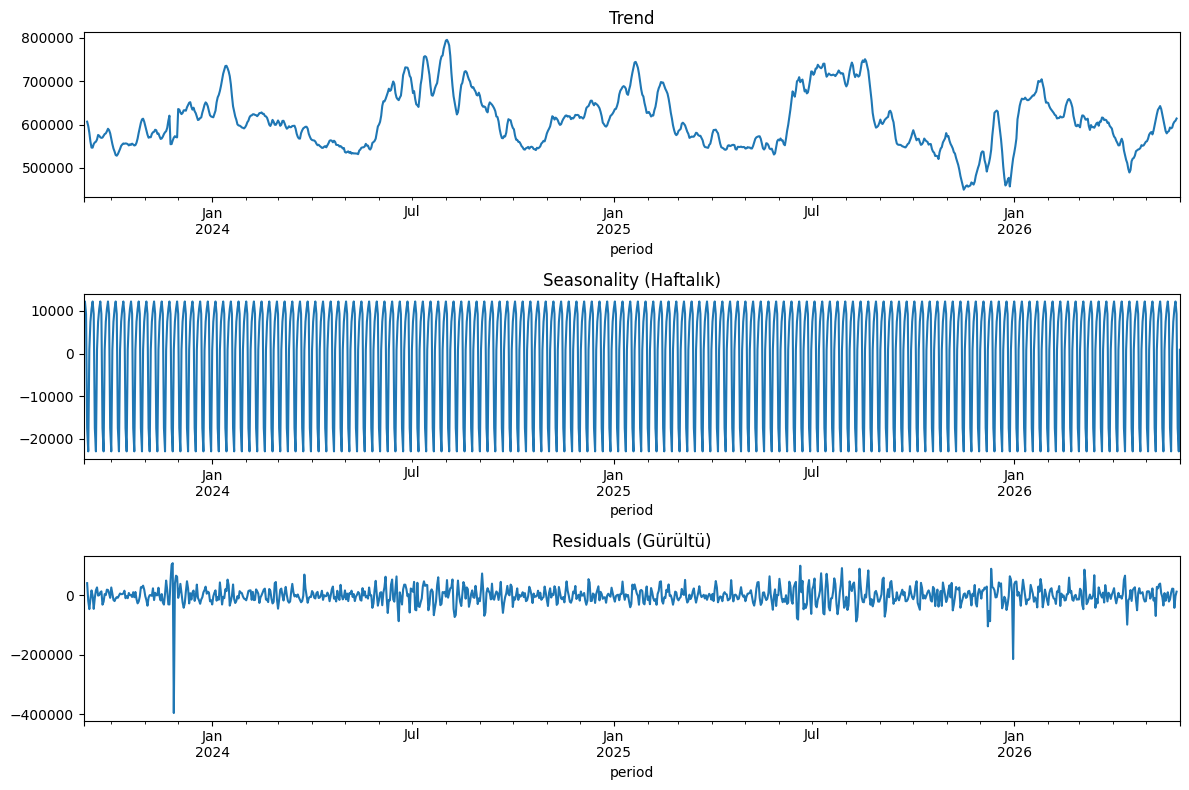

In [107]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Veriyi trend, mevsimsellik ve kalıntı olarak ayır
result = seasonal_decompose(df_final['demand_mwh'], model='additive', period=7)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))
result.trend.plot(ax=ax1, title='Trend')
result.seasonal.plot(ax=ax2, title='Seasonality (Haftalık)')
result.resid.plot(ax=ax3, title='Residuals (Gürültü)')
plt.tight_layout()
plt.show()

## OUTLIER ANALYSIS

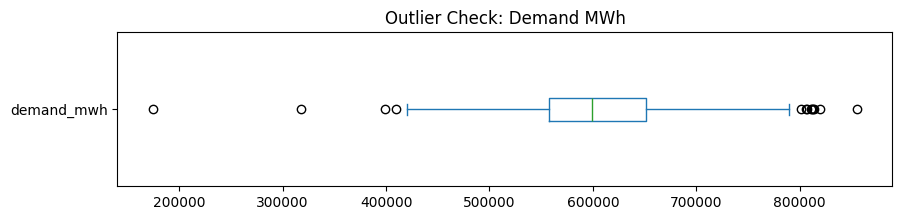

In [108]:
# 1. Visualize outliers using a boxplot
df_final['demand_mwh'].plot(kind='box', vert=False, figsize=(10, 2), title='Outlier Check: Demand MWh')
plt.show()

# 2. Calculate IQR and define bounds
Q1 = df_final['demand_mwh'].quantile(0.25)
Q3 = df_final['demand_mwh'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [109]:
# 3. Identify and count outliers
outliers = df_final[(df_final['demand_mwh'] < lower_bound) | (df_final['demand_mwh'] > upper_bound)]
print(f"Total number of outliers detected: {len(outliers)}")

# 4. Display the dates and values of the outliers
print("\nDates and values containing outliers:")
print(outliers[['demand_mwh', 'day_of_week']])

Total number of outliers detected: 13

Dates and values containing outliers:
            demand_mwh  day_of_week
period                             
2023-11-27    174313.0            0
2024-07-12    812172.0            4
2024-07-31    806743.0            2
2024-08-01    800949.0            3
2024-08-02    855667.0            4
2025-06-20    806216.0            4
2025-07-09    814048.0            2
2025-07-28    810481.0            0
2025-08-13    812564.0            2
2025-08-21    819284.0            3
2025-11-23    409494.0            6
2025-12-08    398973.0            0
2025-12-31    317462.0            2


ADF Statistic: -3.3557008225210248
p-value: 0.01256497587231213
Series is stationary


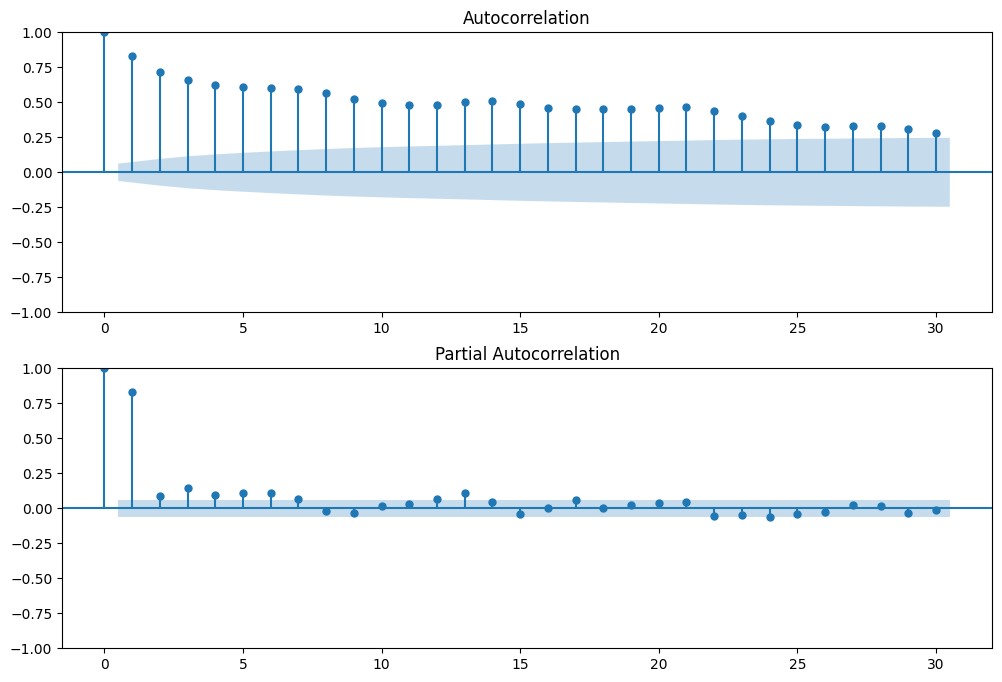

In [110]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. ADF Test for Stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Series is stationary")
    else:
        print("Series is NOT stationary (needs differencing)")

check_stationarity(df_daily['demand_mwh'])

# 2. ACF and PACF plots to identify AR/MA terms
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_daily['demand_mwh'], ax=ax1, lags=30)
plot_pacf(df_daily['demand_mwh'], ax=ax2, lags=30)
plt.show()

## Baseline Evaluation: Seasonal Naive

In [111]:
from sklearn.metrics import mean_squared_error

df_daily['naive_forecast'] = df_daily.index.map(
    lambda x: df_daily.loc[x - pd.DateOffset(days=7), 'demand_mwh'] 
    if (x - pd.DateOffset(days=7)) in df_daily.index else np.nan
)

# Calculate RMSE
df_temp = df_daily.dropna()
rmse_baseline = np.sqrt(mean_squared_error(df_temp['demand_mwh'], df_temp['naive_forecast']))

print(f"Baseline (Seasonal Naive) RMSE: {rmse_baseline:.2f}")

Baseline (Seasonal Naive) RMSE: 66106.30


## SARIMA

In [112]:
from pmdarima import auto_arima
# 1. Hold-out
split_idx = int(len(df_daily) * 0.8)
train = df_daily['demand_mwh'].iloc[:split_idx]
test = df_daily['demand_mwh'].iloc[split_idx:]

# 2. Optimal Parametre Arama (auto_arima ile)
# SARIMA, burada AIC skoruna göre en uygun (p,d,q)(P,D,Q) değerlerini kendisi bulur.
model = auto_arima(
    train,
    seasonal=True,
    m=7,            # Haftalık döngü
    boxcox=True,
    stepwise=True,  # Hızlı arama algoritması
    trace=True,     # İşlem adımlarını yazdırır
    suppress_warnings=True
)

# 3. Tahmin ve Değerlendirme
forecast = model.predict(n_periods=len(test))

rmse_sarima = np.sqrt(mean_squared_error(test, forecast))

print(f"\n--- Model Performansı ---")
print(f"Baseline RMSE: {rmse_baseline:.2f}")
print(f"SARIMA Test RMSE: {rmse_sarima:.2f}")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=19274.454, Time=1.09 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=20168.653, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=19243.670, Time=0.48 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=19714.776, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=23609.535, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=19254.409, Time=0.02 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=19224.692, Time=2.48 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=19462.775, Time=1.49 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=19242.224, Time=0.34 sec
 ARIMA(0,0,0)(2,0,0)[7] intercept   : AIC=20164.360, Time=1.48 sec
 ARIMA(2,0,0)(2,0,0)[7] intercept   : AIC=19223.891, Time=3.24 sec
 ARIMA(2,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(2,0,0)(2,0,1)[7] intercept   : AIC=19737.987, Time=1.44 sec
 ARIMA(2,0,0)(1,0,1)[7] intercept   : AIC=19240.477, Time=0.58 sec
 ARIMA(3,0,0)(2,0,0)[7] i

## FEATURE ENGINEERING

In [114]:
import pandas as pd
import numpy as np

def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    XGBoost modeli için gereken saf özellikleri (features) oluşturur.
    'naive_forecast' gibi gereksiz sütunlar içermez.
    """
    df = df.copy()
    
    # 1. Takvim Özellikleri
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['day_of_year'] = df.index.dayofyear
    
    # 2. İstatistiksel Özellikler (Lag ve Rolling)
    # lag_7: 7 gün önceki değer
    df['lag_7'] = df.index.map(
        lambda x: df.loc[x - pd.Timedelta(days=7), 'demand_mwh'] 
        if (x - pd.Timedelta(days=7)) in df.index else np.nan
    )
    
    # rolling_mean_7d: [t-7, t-1] arasındaki 7 günün ortalaması
    # 'closed' kullanmak yerine doğrudan slice ile güvenli aralık seçiyoruz
    df['rolling_mean_7d'] = df.index.map(
        lambda x: df.loc[x - pd.Timedelta(days=7) : x - pd.Timedelta(days=1), 'demand_mwh'].mean()
        if (x - pd.Timedelta(days=7)) in df.index else np.nan
    )
    
    # Verinin başındaki NaN değerleri temizleyerek saf bir eğitim seti döndür
    return df.dropna()

# Veriyi hazırla ve ilk 10 satırı kontrol et
df_final = create_features(df_daily)
print(df_final.head(10))

            demand_mwh  naive_forecast  day_of_week  month  is_weekend  \
period                                                                   
2023-09-13    573533.0        642704.0            2      9           0   
2023-09-14    557300.0        667271.0            3      9           0   
2023-09-15    518350.0        660456.0            4      9           0   
2023-09-16    532789.0        629919.0            5      9           1   
2023-09-17    554396.0        555180.0            6      9           1   
2023-09-18    592752.0        535203.0            0      9           0   
2023-09-19    582130.0        555126.0            1      9           0   
2023-09-20    585044.0        573533.0            2      9           0   
2023-09-21    592468.0        557300.0            3      9           0   
2023-09-22    591570.0        518350.0            4      9           0   

            day_of_year     lag_7  rolling_mean_7d  
period                                              
2023-

In [ ]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import numpy as np

X = df_final.drop(columns=['demand_mwh'])
y = df_final['demand_mwh']

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# 3. Model ve Parametre Izgarası
xgb_model = xgb.XGBRegressor(objective='reg:squarederror')

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 500]
}

# 4. Grid Search (Tüm eğitme ve validasyon işini burada yapar)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,  # Senin tanımladığın zaman serisi kuralı
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1 # İşlemciyi tam kapasite kullanır
)

# 5. Modeli Eğit ve En İyisini Bul
grid_search.fit(X, y)

print(f"\n--- Optimizasyon Sonuçları ---")
print(f"En İyi Parametreler: {grid_search.best_params_}")
print(f"En İyi RMSE: {-grid_search.best_score_:.2f}")

# Artık en iyi modelin hazır:
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits

--- Optimizasyon Sonuçları ---
En İyi Parametreler: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
En İyi RMSE: 58430.62


In [118]:
# 1. En iyi modelle tüm veri setine tahmin yaptıralım
y_pred = grid_search.best_estimator_.predict(X)

# 2. Şimdi MAPE hesaplayalım
mape = np.mean(np.abs((y - y_pred) / y)) * 100

print(f"Modelin Ortalama Yüzdesel Hata Payı (MAPE): %{mape:.2f}")

Modelin Ortalama Yüzdesel Hata Payı (MAPE): %4.70
